In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('ride_share_churn_dirty_dataset.csv')
df.head()

,Customer_ID,Name,Age,Gender,City,Membership_Type,Tenure_Months,Total_Rides,Average_Ride_Cost,Days_Since_Last_Ride,Cancellation_Rate,Customer_Satisfaction_Score,Payment_Method,App_Usage_Hours_Per_Week,Churn_Status
0,RS100000,Rohan Barad,NaN,Male,Pune,Premium,16,82,1441.39,24,0.70,4.0,Cash,20.4,1
1,RS100001,Rasha Vyas,22.0,Male,Nagpur,Premium,29,295,556.90,118,0.70,2.0,Card,27.9,1
2,RS100002,Kashvi Bassi,44.0,Male,Delhi,Corporate,1,574,1301.14,109,0.07,3.0,Card,3.9,0
3,RS100003,Nishith Singh,19.0,Male,Mumbai,Regular,23,121,2065.29,160,0.35,NaN,Cash,3.5,1
4,RS100004,Suhana Bhattacharyya,37.0,Male,Chennai,Gold,65,115,1880.35,80,0.69,9.0,Wallet,10.9,1


In [3]:
ds= df.copy()

# 1. Understanding data

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20760 entries, 0 to 20759
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  20760 non-null  object 
 1   Name                         20707 non-null  object 
 2   Age                          19790 non-null  float64
 3   Gender                       20760 non-null  object 
 4   City                         20760 non-null  object 
 5   Membership_Type              20760 non-null  object 
 6   Tenure_Months                20760 non-null  int64  
 7   Total_Rides                  20760 non-null  int64  
 8   Average_Ride_Cost            19796 non-null  float64
 9   Days_Since_Last_Ride         20760 non-null  int64  
 10  Cancellation_Rate            20760 non-null  float64
 11  Customer_Satisfaction_Score  19773 non-null  float64
 12  Payment_Method               20760 non-null  object 
 13  App_Usage_Hours_

In [5]:
ds.describe()

,Age,Tenure_Months,Total_Rides,Average_Ride_Cost,Days_Since_Last_Ride,Cancellation_Rate,Customer_Satisfaction_Score,App_Usage_Hours_Per_Week,Churn_Status
count,19790.000000,20760.000000,20760.000000,19796.000000,20760.000000,20760.000000,19773.000000,19778.000000,20760.000000
mean,44.320162,36.181888,301.542293,2823.779151,89.336320,0.399974,5.499115,17.438846,0.482370
std,20.445888,20.443184,173.508297,10066.695801,51.995858,0.230650,2.855630,10.139213,0.499701
min,-5.000000,1.000000,1.000000,50.040000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,19.000000,152.000000,681.440000,45.000000,0.200000,3.000000,8.700000,0.000000
50%,43.000000,36.000000,301.000000,1305.505000,89.000000,0.400000,6.000000,17.300000,0.000000
75%,57.000000,54.000000,453.000000,1941.907500,134.000000,0.600000,8.000000,26.300000,1.000000
max,200.000000,71.000000,599.000000,99994.000000,179.000000,0.800000,10.000000,35.000000,1.000000


In [6]:
ds.columns= ds.columns.str.lower()

In [7]:
ds.head(2)

,customer_id,name,age,gender,city,membership_type,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,payment_method,app_usage_hours_per_week,churn_status
0,RS100000,Rohan Barad,NaN,Male,Pune,Premium,16,82,1441.39,24,0.7,4.0,Cash,20.4,1
1,RS100001,Rasha Vyas,22.0,Male,Nagpur,Premium,29,295,556.90,118,0.7,2.0,Card,27.9,1


# 2. Handling Missing Values

In [8]:
ds.isnull().sum()

customer_id                      0
name                            53
age                            970
gender                           0
city                             0
membership_type                  0
tenure_months                    0
total_rides                      0
average_ride_cost              964
days_since_last_ride             0
cancellation_rate                0
customer_satisfaction_score    987
payment_method                   0
app_usage_hours_per_week       982
churn_status                     0
dtype: int64

In [9]:
# Categorical columns
ds['gender'] = ds['gender'].fillna(ds['gender'].mode()[0])
ds['city'] = ds['city'].fillna(ds['city'].mode()[0])
ds['membership_type'] = ds['membership_type'].fillna(ds['membership_type'].mode()[0])
ds['payment_method'] = ds['payment_method'].fillna(ds['payment_method'].mode()[0])

# Numeric columns
ds['customer_id'] = ds['customer_id'].fillna(ds['customer_id'].mode()[0])
ds['age'] = ds['age'].fillna(ds['age'].mode()[0])
ds['tenure_months'] = ds['tenure_months'].fillna(ds['tenure_months'].mode()[0])
ds['total_rides'] = ds['total_rides'].fillna(ds['total_rides'].mode()[0])
ds['average_ride_cost'] = ds['average_ride_cost'].fillna(ds['average_ride_cost'].mode()[0])
ds['days_since_last_ride'] = ds['days_since_last_ride'].fillna(ds['days_since_last_ride'].mode()[0])
ds['cancellation_rate'] = ds['cancellation_rate'].fillna(ds['cancellation_rate'].mode()[0])
ds['customer_satisfaction_score'] = ds['customer_satisfaction_score'].fillna(ds['customer_satisfaction_score'].mode()[0])
ds['app_usage_hours_per_week'] = ds['app_usage_hours_per_week'].fillna(ds['app_usage_hours_per_week'].mode()[0])
ds['app_usage_hours_per_week'] = ds['app_usage_hours_per_week'].fillna(ds['app_usage_hours_per_week'].mode()[0])
ds['churn_status'] = ds['churn_status'].fillna(ds['churn_status'].mode()[0])

In [10]:
ds.isnull().sum()

customer_id                     0
name                           53
age                             0
gender                          0
city                            0
membership_type                 0
tenure_months                   0
total_rides                     0
average_ride_cost               0
days_since_last_ride            0
cancellation_rate               0
customer_satisfaction_score     0
payment_method                  0
app_usage_hours_per_week        0
churn_status                    0
dtype: int64

# 3. Handling Duplicates

In [11]:
if all(col in ds.columns for col in ['customer_id', 'name', 'churn_status']):
    ds = ds.drop_duplicates(subset=['customer_id', 'name', 'churn_status'], keep='first')
elif all(col in ds.columns for col in ['customer_id', 'churn_status']):
    ds = ds.drop_duplicates(subset=['customer_id', 'churn_status'], keep='first')
else:
    ds = ds.drop_duplicates(subset=['city', 'membership_type', 'tenure_months', 'total_rides', 'average_ride_cost', 'days_since_last_ride', 'cancellation_rate', 'payment_method', 'churn_status'], keep='first')

# 4. Remove Extra

In [12]:
ds.columns

Index(['customer_id', 'name', 'age', 'gender', 'city', 'membership_type',
       'tenure_months', 'total_rides', 'average_ride_cost',
       'days_since_last_ride', 'cancellation_rate',
       'customer_satisfaction_score', 'payment_method',
       'app_usage_hours_per_week', 'churn_status'],
      dtype='object')

In [13]:
cols = ['age', 'gender', 'city', 'membership_type',
       'tenure_months', 'total_rides', 'average_ride_cost',
       'days_since_last_ride', 'cancellation_rate',
       'customer_satisfaction_score', 'payment_method',
       'app_usage_hours_per_week', 'churn_status']

ds = ds[cols]
ds.head(2)

,age,gender,city,membership_type,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,payment_method,app_usage_hours_per_week,churn_status
0,40.0,Male,Pune,Premium,16,82,1441.39,24,0.7,4.0,Cash,20.4,1
1,22.0,Male,Nagpur,Premium,29,295,556.90,118,0.7,2.0,Card,27.9,1


In [14]:
ds.head()

,age,gender,city,membership_type,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,payment_method,app_usage_hours_per_week,churn_status
0,40.0,Male,Pune,Premium,16,82,1441.39,24,0.70,4.0,Cash,20.4,1
1,22.0,Male,Nagpur,Premium,29,295,556.90,118,0.70,2.0,Card,27.9,1
2,44.0,Male,Delhi,Corporate,1,574,1301.14,109,0.07,3.0,Card,3.9,0
3,19.0,Male,Mumbai,Regular,23,121,2065.29,160,0.35,6.0,Cash,3.5,1
4,37.0,Male,Chennai,Gold,65,115,1880.35,80,0.69,9.0,Wallet,10.9,1


# datatype correction

In [15]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20018 entries, 0 to 20753
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          20018 non-null  float64
 1   gender                       20018 non-null  object 
 2   city                         20018 non-null  object 
 3   membership_type              20018 non-null  object 
 4   tenure_months                20018 non-null  int64  
 5   total_rides                  20018 non-null  int64  
 6   average_ride_cost            20018 non-null  float64
 7   days_since_last_ride         20018 non-null  int64  
 8   cancellation_rate            20018 non-null  float64
 9   customer_satisfaction_score  20018 non-null  float64
 10  payment_method               20018 non-null  object 
 11  app_usage_hours_per_week     20018 non-null  float64
 12  churn_status                 20018 non-null  int64  
dtypes: float64(5), int64(

In [16]:
# ds['monthlycharges'] = pd.to_numeric(ds['monthlycharges'], errors='coerce')

# 4. Extracting Features

In [17]:
cols = [
    'age', 'gender', 'city', 'membership_type',
    'tenure_months', 'total_rides', 'average_ride_cost',
    'days_since_last_ride', 'cancellation_rate',
    'customer_satisfaction_score', 'payment_method',
    'app_usage_hours_per_week', 'churn_status'
]

ds = ds[cols]
ds.head(2)

,age,gender,city,membership_type,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,payment_method,app_usage_hours_per_week,churn_status
0,40.0,Male,Pune,Premium,16,82,1441.39,24,0.7,4.0,Cash,20.4,1
1,22.0,Male,Nagpur,Premium,29,295,556.90,118,0.7,2.0,Card,27.9,1


In [18]:
ds['churn_status'].unique()

array([1, 0])

In [19]:
ds["churn_status"] = ds["churn_status"].replace(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0, '  Yes ': 1, '  No ': 0}
).astype(int)

In [20]:
ds['churn_status'].value_counts()

churn_status
0    10355
1     9663
Name: count, dtype: int64

# 5. Encoding

In [21]:
print(ds['gender'].unique())
print(ds['city'].unique())
print(ds['membership_type'].unique())
print(ds['payment_method'].unique())

ds['gender'].str.strip()
ds['city'].str.strip()
ds['membership_type'].str.strip()
ds['payment_method'].str.strip()

['Male' 'Female' 'FEMALE' 'Other' 'unknown' '??' 'male ']
['Pune' 'Nagpur' 'Delhi' 'Mumbai' 'Chennai' 'Bangalore' 'Hyderabad'
 'Kolkata' 'Ahmedabad' 'Jaipur']
['Premium' 'Corporate' 'Regular' 'Gold']
['Cash' 'Card' 'Wallet' 'UPI']


0          Cash
1          Card
2          Card
3          Cash
4        Wallet
          ...  
20602      Card
20705      Card
20716    Wallet
20740       UPI
20753      Card
Name: payment_method, Length: 20018, dtype: object

In [22]:
enc = pd.get_dummies(
    data=ds,
    columns=[
        'gender',
        'city',
        'membership_type',
        'payment_method'
    ],
    drop_first=True,
    dtype=int
)

ds = enc

ds.head(2)

,age,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,app_usage_hours_per_week,churn_status,gender_FEMALE,...,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune,membership_type_Gold,membership_type_Premium,membership_type_Regular,payment_method_Cash,payment_method_UPI,payment_method_Wallet
0,40.0,16,82,1441.39,24,0.7,4.0,20.4,1,0,...,0,0,0,1,0,1,0,1,0,0
1,22.0,29,295,556.90,118,0.7,2.0,27.9,1,0,...,0,0,1,0,0,1,0,0,0,0


# 6. Train Test Split

In [23]:
X= ds.drop(columns=['churn_status'])
# y= ds[['churn']]
y= ds['churn_status']

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
X_train.shape, X_test.shape

((16014, 29), (4004, 29))

In [26]:
y_train.shape, y_test.shape

((16014,), (4004,))

# 7. Outlier remove

In [27]:
ds.head()

,age,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,app_usage_hours_per_week,churn_status,gender_FEMALE,...,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune,membership_type_Gold,membership_type_Premium,membership_type_Regular,payment_method_Cash,payment_method_UPI,payment_method_Wallet
0,40.0,16,82,1441.39,24,0.70,4.0,20.4,1,0,...,0,0,0,1,0,1,0,1,0,0
1,22.0,29,295,556.90,118,0.70,2.0,27.9,1,0,...,0,0,1,0,0,1,0,0,0,0
2,44.0,1,574,1301.14,109,0.07,3.0,3.9,0,0,...,0,0,0,0,0,0,0,0,0,0
3,19.0,23,121,2065.29,160,0.35,6.0,3.5,1,0,...,0,1,0,0,0,0,1,1,0,0
4,37.0,65,115,1880.35,80,0.69,9.0,10.9,1,0,...,0,0,0,0,1,0,0,0,0,1


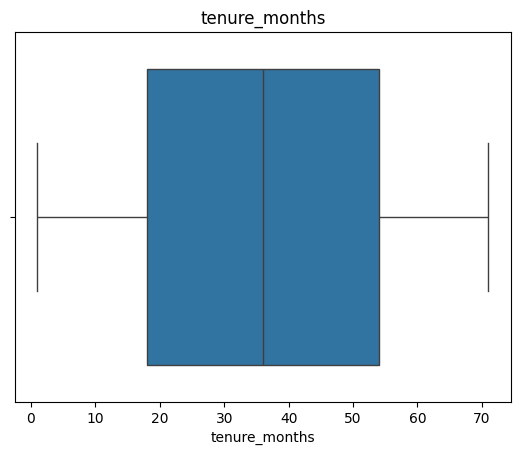

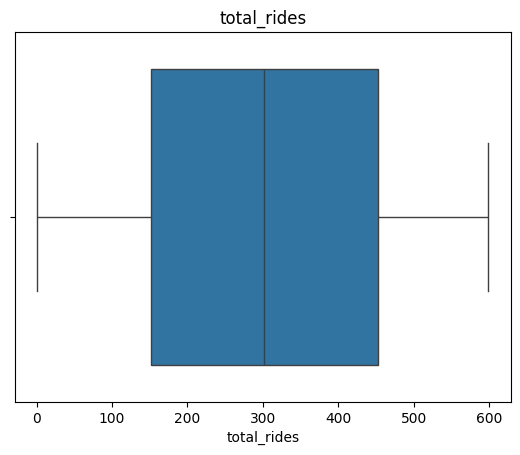

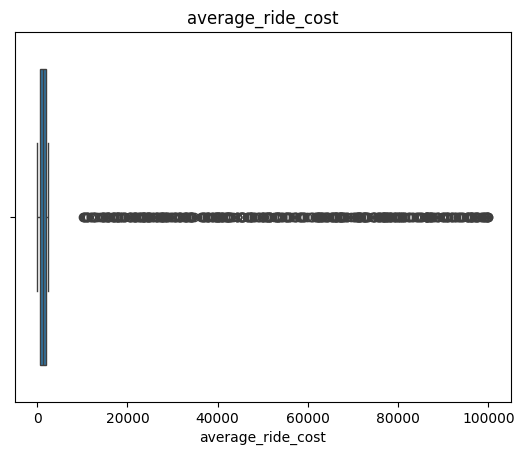

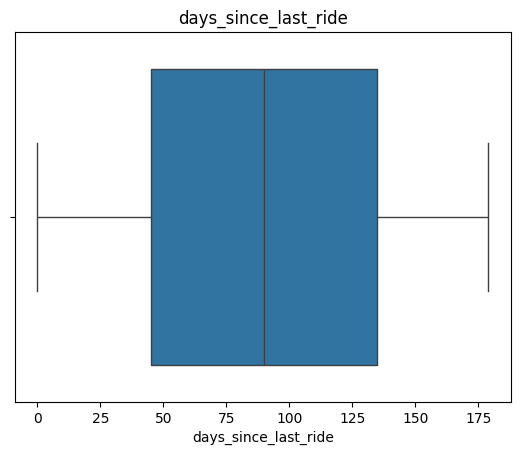

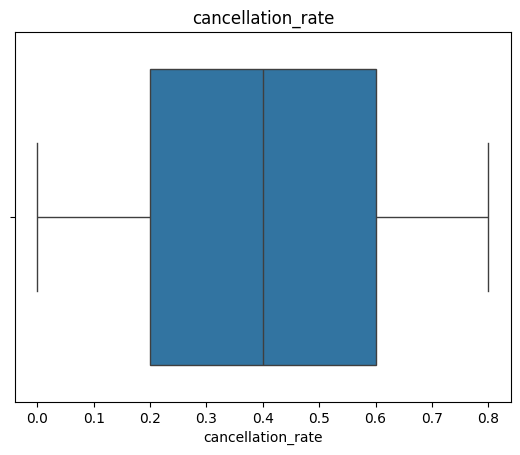

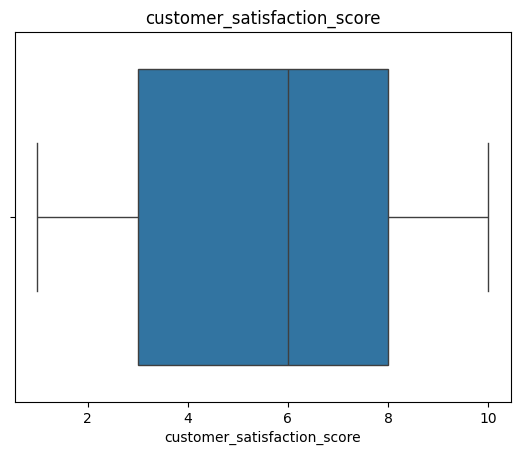

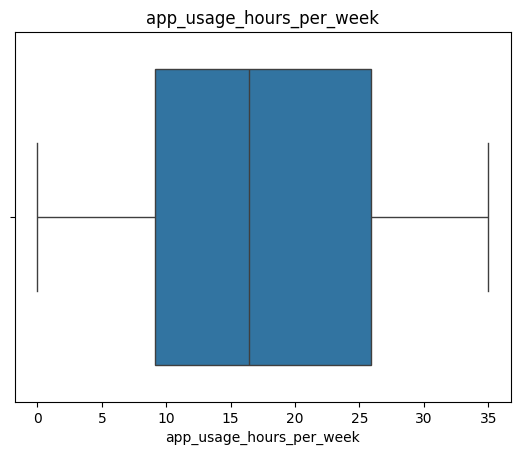

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['tenure_months', 'total_rides', 'average_ride_cost', 'days_since_last_ride', 'cancellation_rate', 'customer_satisfaction_score', 'app_usage_hours_per_week']:
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

In [29]:
def handle_outliers(ds, cols):
    for col in cols:
        Q1 = ds[col].quantile(0.25)
        Q3 = ds[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # clip values
        ds[col] = ds[col].clip(lower, upper)

    return ds

In [30]:
num_cols = [
   'tenure_months', 'total_rides', 'average_ride_cost', 'days_since_last_ride', 'cancellation_rate', 'customer_satisfaction_score', 'app_usage_hours_per_week'
]

X_train = handle_outliers(X_train, num_cols)

# 8. Scaling data

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # converted into array
X_test = scaler.transform(X_test)

# 9. Model Training

In [32]:
print(pd.DataFrame(X_train).isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
dtype: int64


In [33]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [34]:
print(X_train.isnull().sum())

age                            0
tenure_months                  0
total_rides                    0
average_ride_cost              0
days_since_last_ride           0
cancellation_rate              0
customer_satisfaction_score    0
app_usage_hours_per_week       0
gender_FEMALE                  0
gender_Female                  0
gender_Male                    0
gender_Other                   0
gender_male                    0
gender_unknown                 0
city_Bangalore                 0
city_Chennai                   0
city_Delhi                     0
city_Hyderabad                 0
city_Jaipur                    0
city_Kolkata                   0
city_Mumbai                    0
city_Nagpur                    0
city_Pune                      0
membership_type_Gold           0
membership_type_Premium        0
membership_type_Regular        0
payment_method_Cash            0
payment_method_UPI             0
payment_method_Wallet          0
dtype: int64


# again train model

In [35]:
from sklearn.svm import LinearSVC

# Faster SVM for large datasets
model_svm = LinearSVC(
    C=1,
    random_state=42,
    max_iter=5000
)

model_svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random

In [36]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [37]:
model_svm.score(X_train, y_train)

0.6423129761458723

In [38]:
model_svm.score(X_test, y_test)

0.6550949050949051

In [39]:
model_rf.score(X_train, y_train)

0.7121268889721494

In [40]:
model_rf.score(X_test, y_test)

0.6928071928071928

In [45]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:45:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [46]:
model_xgb.score(X_train, y_train)

0.759897589609092

In [47]:
model_xgb.score(X_test, y_test)

0.6833166833166833

In [50]:
# =========================================
# Compare Gym Models & Select Best Model
# =========================================

models = {
    "SVM": model_svm,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

best_model_name = None
best_model = None
best_score = 0

print("\n===== GYM MODEL COMPARISON =====\n")

for name, model in models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"{name}")
    print(f"Training Accuracy : {train_score:.4f}")
    print(f"Testing Accuracy  : {test_score:.4f}")
    print("-" * 35)

    # Select Model With Highest Test Accuracy
    if test_score > best_score:
        best_score = test_score
        best_model_name = name
        best_model = model

# =========================================
# Final Best Model
# =========================================

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy : {best_score:.4f}")


===== GYM MODEL COMPARISON =====

SVM
Training Accuracy : 0.6423
Testing Accuracy  : 0.6551
-----------------------------------
Random Forest
Training Accuracy : 0.7121
Testing Accuracy  : 0.6928
-----------------------------------
XGBoost
Training Accuracy : 0.7599
Testing Accuracy  : 0.6833
-----------------------------------

Best Model Selected : Random Forest
Best Accuracy : 0.6928


In [52]:
new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

In [53]:
new_customer['age'] = 30
new_customer['tenure_months'] = 18
new_customer['total_rides'] = 120
new_customer['average_ride_cost'] = 450
new_customer['days_since_last_ride'] = 5
new_customer['cancellation_rate'] = 0.10
new_customer['customer_satisfaction_score'] = 4
new_customer['app_usage_hours_per_week'] = 15

In [54]:
new_customer['gender_Male'] = 1

new_customer['city_Nagpur'] = 1

new_customer['membership_type_Premium'] = 1

new_customer['payment_method_UPI'] = 1

In [55]:
new_customer_scaled = scaler.transform(new_customer)

# Convert Back To DataFrame
new_customer_scaled = pd.DataFrame(
    new_customer_scaled,
    columns=X.columns
)


In [56]:
prediction = best_model.predict(new_customer_scaled)

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy       : {best_score:.4f}")

if prediction[0] == 1:
    print("\nPrediction : Customer will leave ride service")
else:
    print("\nPrediction : Customer will stay in ride service")


Best Model Selected : Random Forest
Best Accuracy       : 0.6928

Prediction : Customer will stay in ride service


In [57]:
prob = best_model.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")


Stay Probability  : 78.18%
Leave Probability : 21.82%


In [58]:
# =========================================
# Hyperparameter Tuning For Ride Share Churn
# Using XGBoost
# =========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================
# XGBoost Parameter Grid
# =========================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# =========================================
# Base XGBoost Model
# =========================================

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# =========================================
# Randomized Search CV
# =========================================

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# =========================================
# Train Tuned Model
# =========================================

random_search.fit(X_train, y_train)

# =========================================
# Best Parameters
# =========================================

print("\nBest Parameters:\n")
print(random_search.best_params_)

# =========================================
# Best Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# =========================================
# Accuracy Scores
# =========================================

train_score = best_xgb.score(X_train, y_train)
test_score = best_xgb.score(X_test, y_test)

print("\nTraining Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

# =========================================
# New Ride Share Customer Data
# =========================================

new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

# Numeric Features
new_customer['age'] = 30
new_customer['tenure_months'] = 18
new_customer['total_rides'] = 120
new_customer['average_ride_cost'] = 450
new_customer['days_since_last_ride'] = 5
new_customer['cancellation_rate'] = 0.10
new_customer['customer_satisfaction_score'] = 4
new_customer['app_usage_hours_per_week'] = 15

# Encoded Features
new_customer['gender_Male'] = 1
new_customer['city_Nagpur'] = 1
new_customer['membership_type_Premium'] = 1
new_customer['payment_method_UPI'] = 1

# =========================================
# Scale Data
# =========================================

new_customer_scaled = scaler.transform(new_customer)

# Convert Back To DataFrame
new_customer_scaled = pd.DataFrame(
    new_customer_scaled,
    columns=X.columns
)

# =========================================
# Prediction Using Tuned XGBoost
# =========================================

prediction = best_xgb.predict(new_customer_scaled)

if prediction[0] == 1:
    print("\nCustomer will leave ride service")
else:
    print("\nCustomer will stay in ride service")

# =========================================
# Probability Prediction
# =========================================

prob = best_xgb.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:50:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters:

{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Training Accuracy : 0.6814662170600725
Testing Accuracy  : 0.6870629370629371

Customer will stay in ride service

Stay Probability  : 76.17%
Leave Probability : 23.83%


In [59]:
import joblib

# Save SVM Model
joblib.dump(model_rf, "ride_rf_model.pkl")

# Save Scaler
joblib.dump(scaler, "ride_scaler.pkl")

print("Model  Saved Successfully")
print("Scaler ride Saved Successfully")

Model  Saved Successfully
Scaler ride Saved Successfully


In [48]:
ds.head(3)

,age,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,app_usage_hours_per_week,churn_status,gender_FEMALE,...,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune,membership_type_Gold,membership_type_Premium,membership_type_Regular,payment_method_Cash,payment_method_UPI,payment_method_Wallet
0,40.0,16,82,1441.39,24,0.70,4.0,20.4,1,0,...,0,0,0,1,0,1,0,1,0,0
1,22.0,29,295,556.90,118,0.70,2.0,27.9,1,0,...,0,0,1,0,0,1,0,0,0,0
2,44.0,1,574,1301.14,109,0.07,3.0,3.9,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
X_train.head(3)

,age,tenure_months,total_rides,average_ride_cost,days_since_last_ride,cancellation_rate,customer_satisfaction_score,app_usage_hours_per_week,gender_FEMALE,gender_Female,...,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune,membership_type_Gold,membership_type_Premium,membership_type_Regular,payment_method_Cash,payment_method_UPI,payment_method_Wallet
0,0.978259,1.113869,0.255256,-0.527563,-0.418406,1.349106,0.888360,0.604705,-0.067671,1.144475,...,-0.336056,-0.336286,2.987990,-0.330156,-0.571245,-0.579417,1.716756,-0.574322,-0.571149,-0.574803
1,0.731384,0.136956,-1.437862,-0.547831,0.776175,-0.391381,0.530234,-1.216827,-0.067671,-0.873763,...,-0.336056,-0.336286,2.987990,-0.330156,1.750562,-0.579417,-0.582494,1.741184,-0.571149,-0.574803
2,-0.651115,0.136956,-1.080810,0.419198,-0.187196,0.478862,-1.260396,1.475437,-0.067671,-0.873763,...,-0.336056,-0.336286,-0.334673,3.028874,-0.571245,1.725872,-0.582494,1.741184,-0.571149,-0.574803


In [51]:
df.head()

,Customer_ID,Name,Age,Gender,City,Membership_Type,Tenure_Months,Total_Rides,Average_Ride_Cost,Days_Since_Last_Ride,Cancellation_Rate,Customer_Satisfaction_Score,Payment_Method,App_Usage_Hours_Per_Week,Churn_Status
0,RS100000,Rohan Barad,NaN,Male,Pune,Premium,16,82,1441.39,24,0.70,4.0,Cash,20.4,1
1,RS100001,Rasha Vyas,22.0,Male,Nagpur,Premium,29,295,556.90,118,0.70,2.0,Card,27.9,1
2,RS100002,Kashvi Bassi,44.0,Male,Delhi,Corporate,1,574,1301.14,109,0.07,3.0,Card,3.9,0
3,RS100003,Nishith Singh,19.0,Male,Mumbai,Regular,23,121,2065.29,160,0.35,NaN,Cash,3.5,1
4,RS100004,Suhana Bhattacharyya,37.0,Male,Chennai,Gold,65,115,1880.35,80,0.69,9.0,Wallet,10.9,1
